In [3]:
from abc import ABC, abstractmethod
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('data.csv')

In [4]:
print("Data Types:")
print(df.dtypes)
print("\nNon-null Counts:")
print(df.count())
print("\nData types and non null Counts:")
print(df.info())

Data Types:
crop        object
moisture     int64
temp         int64
pump         int64
dtype: object

Non-null Counts:
crop        200
moisture    200
temp        200
pump        200
dtype: int64

Data types and non null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   crop      200 non-null    object
 1   moisture  200 non-null    int64 
 2   temp      200 non-null    int64 
 3   pump      200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB
None


In [6]:

print("Summary Statistics (Numerical Features:")
print(df.describe())
print("\nSummary Statistics (Categorical Features:")
print(df.describe(include=["O"]))


Summary Statistics (Numerical Features:
          moisture        temp        pump
count   200.000000  200.000000  200.000000
mean    633.085000   27.750000    0.750000
std     279.077118   10.869602    0.434099
min       4.000000   10.000000    0.000000
25%     500.500000   18.000000    0.750000
50%     693.500000   28.000000    1.000000
75%     850.750000   38.000000    1.000000
max    1022.000000   45.000000    1.000000

Summary Statistics (Categorical Features:
          crop
count      200
unique       1
top     cotton
freq       200


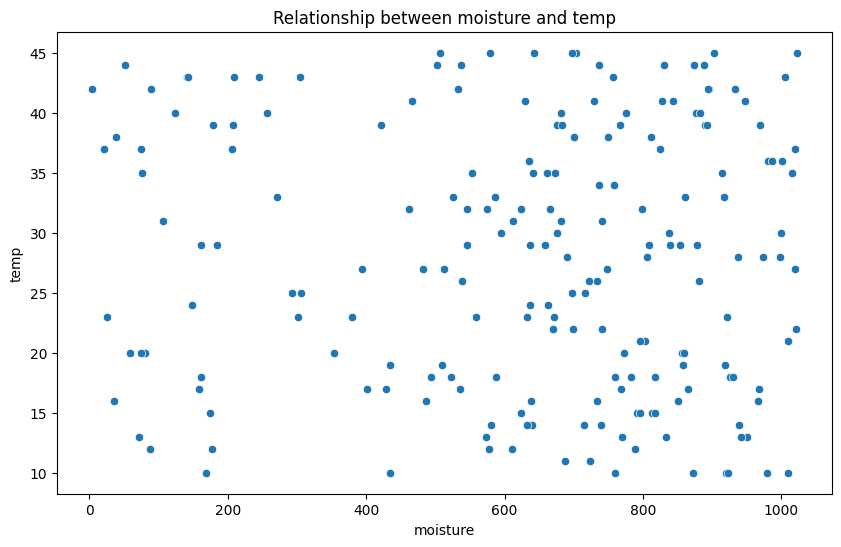

In [7]:
def analyze(df: pd.DataFrame, feature1: str, feature2: str) -> None:
    plt.figure(figsize=(10,6))
    sns.scatterplot(x=feature1, y=feature2, data = df)
    plt.title(f"Relationship between {feature1} and {feature2}")
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.show()

analyze(df ,"moisture", "temp")

In [8]:
print("\nChecking for duplicates:")
print(df.duplicated().sum())

print("\nChecking for missing values:")
print(df.isnull().sum())



Checking for duplicates:
0

Checking for missing values:
crop        0
moisture    0
temp        0
pump        0
dtype: int64


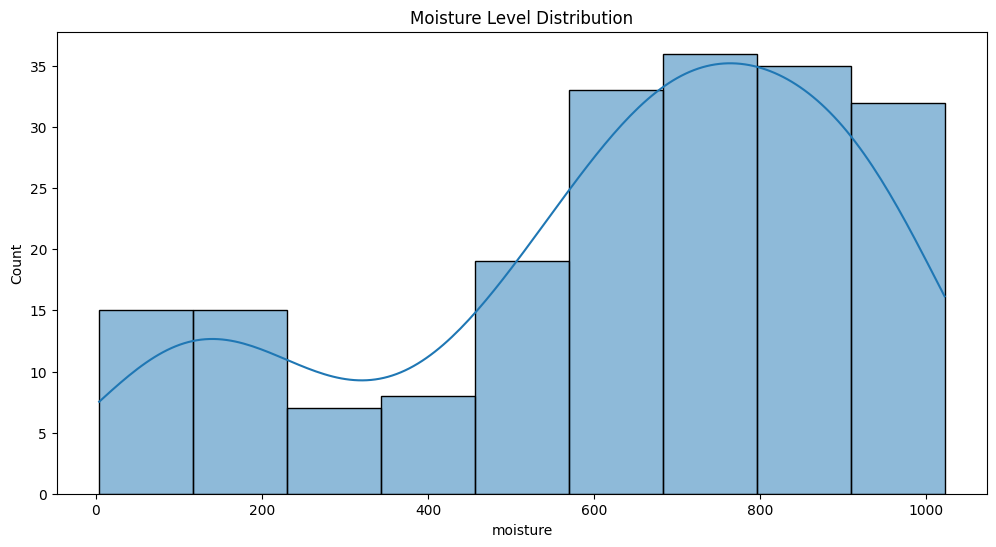

In [9]:
plt.figure(figsize=(12, 6))
sns.histplot(df['moisture'], kde=True)
plt.title("Moisture Level Distribution")
plt.show()


In [11]:
df['moisture'].corr(df['temp'])

np.float64(-0.04596932620032192)

In [12]:
from sklearn.model_selection import train_test_split

X = df[['moisture', 'temp']]
Y = df['pump']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


---
1️⃣ Logistic Regression

    Good if relationships are linear.

    Fast and interpretable, but may underperform on complex data.

    Best for: Well-separated classes or binary classification (0 or 1).

2️⃣ Decision Tree

    Simple to understand (like a flowchart).

    Handles both numerical and categorical data.

    Prone to overfitting, but good for a baseline.

⚡ B. Performance-Driven Models (More complex)

3️⃣ Random Forest 🌳

    Ensemble of Decision Trees → reduces overfitting.

    Handles missing data & outliers well.

    Best for: Medium to large datasets with a mix of features.

4️⃣ Gradient Boosting (e.g., XGBoost, LightGBM, CatBoost)

    Boosting technique: builds models sequentially, correcting errors.

    More accurate but slower to train than Random Forest.

    Best for: Highly structured data or when you need fine-tuning.

5️⃣ Support Vector Machine (SVM)

    Powerful for high-dimensional data.

    Works well on small datasets, but scales poorly with large ones.

    Best for: Clear margin of separation or complex boundaries.
  
  ---

In [15]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import time

# Define models
models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("SVM (Linear)", SVC(kernel='linear')),
    ("K-Nearest Neighbors", KNeighborsClassifier()),
    ("Random Forest", RandomForestClassifier())
]


# Function to evaluate models on train-test split
def compare_models_train_test():
    print("\n **Train-Test Split Performance**\n")
    for name, model in models:
        start_time = time.time()

        # Training and predicting
        model.fit(X_train, Y_train)
        predictions = model.predict(X_test)

        # Metrics
        accuracy = accuracy_score(Y_test, predictions)
        precision = precision_score(Y_test, predictions, average='weighted', zero_division=0)
        recall = recall_score(Y_test, predictions, average='weighted', zero_division=0)
        f1 = f1_score(Y_test, predictions, average='weighted', zero_division=0)

        end_time = time.time()
        duration = round(end_time - start_time, 2)

        # Output results
        print(f"🔹 **{name}**")
        print(f"   Accuracy: {accuracy:.2f}")
        print(f"   Precision: {precision:.2f}")
        print(f"   Recall: {recall:.2f}")
        print(f"   F1-Score: {f1:.2f}")
        print(f"   Training Time: {duration}s")
        print("-" * 30)


# Function to evaluate models with cross-validation
def compare_models_cross_validation():
    print("\n📌 **Cross-Validation Performance (5-Fold)**\n")
    for name, model in models:
        try:
            start_time = time.time()

            # Cross-validation scores
            cv_scores = cross_val_score(model, X, Y, cv=5, scoring='accuracy')
            mean_accuracy = round(cv_scores.mean() * 100, 2)

            end_time = time.time()
            duration = round(end_time - start_time, 2)

            # Output results
            print(f"🔹 **{name}**")
            print(f"   Mean Accuracy (5-Fold): {mean_accuracy}%")
            print(f"   Cross-Validation Time: {duration}s")
            print("-" * 30)

        except Exception as e:
            print(f"⚠️ Model {name} failed: {e}")


# Run both comparisons
compare_models_train_test()
print("\n" + "=" * 50 + "\n")
compare_models_cross_validation()



 **Train-Test Split Performance**

🔹 **Logistic Regression**
   Accuracy: 1.00
   Precision: 1.00
   Recall: 1.00
   F1-Score: 1.00
   Training Time: 0.05s
------------------------------
🔹 **SVM (Linear)**
   Accuracy: 1.00
   Precision: 1.00
   Recall: 1.00
   F1-Score: 1.00
   Training Time: 0.02s
------------------------------
🔹 **K-Nearest Neighbors**
   Accuracy: 0.97
   Precision: 0.98
   Recall: 0.97
   F1-Score: 0.97
   Training Time: 0.02s
------------------------------
🔹 **Random Forest**
   Accuracy: 1.00
   Precision: 1.00
   Recall: 1.00
   F1-Score: 1.00
   Training Time: 0.4s
------------------------------



📌 **Cross-Validation Performance (5-Fold)**

🔹 **Logistic Regression**
   Mean Accuracy (5-Fold): 99.0%
   Cross-Validation Time: 0.21s
------------------------------
🔹 **SVM (Linear)**
   Mean Accuracy (5-Fold): 99.0%
   Cross-Validation Time: 0.06s
------------------------------
🔹 **K-Nearest Neighbors**
   Mean Accuracy (5-Fold): 98.5%
   Cross-Validation Time: 

In [18]:
import joblib


log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, Y_train)

joblib.dump(log_model, 'm6.pkl')
print("\n Model saved")

loaded_model = joblib.load('m6.pkl')
test_sample = X_test.iloc[0].values.reshape(1, -1)
result = loaded_model.predict(test_sample)

print(f"\n {result[0]}")


 Model saved

 1


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
